Setup and Clone

In [ ]:
import os

%cd /content

repo_name = "Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual"
if not os.path.exists(repo_name):
  !git clone https://github.com/ayiii-a/Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual.git


%cd /content/{repo_name}

from google.colab import drive
drive.mount('/content/drive')

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

!pip install -q transformers accelerate

/content
/content/Detecting-LLM-Generated-Social-Media-Accounts-Using-Semantic-and-Textual
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Loading and Distribution Visualization

In [ ]:
import pandas as pd
import json
import numpy as np
from collections import Counter
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# start loading botsim-24 metadata and json
print("start loading and extracting 6-dim multi-modal features from botsim-24...")

# load metadata from users.csv
users_df = pd.read_csv('./data/Users.csv')

# based on botsim-24 structure: first 1907 are human (0), last 1000 are bots (1)
labels = [0] * 1907 + [1] * 1000
if len(users_df) == len(labels):
    users_df['label'] = labels
else:
    # fallback if size varies
    users_df['label'] = users_df['character_setting'].notna().astype(int)

# load json data
with open('./data/user_post_comment.json', 'r') as f:
    posts_data = json.load(f)

dataset = []

# extract text and metadata features
for idx, row in users_df.iterrows():
    user_id = row['user_id']
    label = row['label']

    # basic behavioral features from csv
    has_desc = 1.0 if pd.notna(row.get('description')) else 0.0
    sub_num = row.get('submission_num', 0)
    com_num = row.get('comment_num', 0)

    # feature 1: activity ratio
    activity_ratio = sub_num / (com_num + 1.0)

    # feature 2 (new): interaction depth topology (level 2 comment ratio)
    c1_num = row.get('comment_num_1', 0)
    c2_num = row.get('comment_num_2', 0)
    depth_ratio = c2_num / (c1_num + c2_num + 1e-9)

    if user_id in posts_data:
        user_content = posts_data[user_id]
        texts = []
        subreddits = [] # for topic entropy calculation
        lengths = []    # for intra-user variance calculation
        timestamps = [] # for temporal burstiness calculation

        # extract submissions
        if 'posts' in user_content:
            for p in user_content['posts']:
                if 'posts' in p and pd.notna(p['posts']):
                    text = str(p['posts'])
                    texts.append(text)
                    lengths.append(len(text.split()))
                    if 'subreddit' in p:
                        subreddits.append(p['subreddit'])
                    if 'created_utc' in p and pd.notna(p['created_utc']):
                        try:
                            timestamps.append(datetime.strptime(p['created_utc'], "%Y-%m-%d %H:%M:%S"))
                        except:
                            pass

        # extract comments
        for level in ['comment_1', 'comment_2']:
            if level in user_content:
                for c in user_content[level]:
                    if 'comment_body' in c and pd.notna(c['comment_body']):
                        text = str(c['comment_body'])
                        texts.append(text)
                        lengths.append(len(text.split()))
                        if 'subreddit' in c:
                            subreddits.append(c['subreddit'])
                        if 'created_utc' in c and pd.notna(c['created_utc']):
                            try:
                                timestamps.append(datetime.strptime(c['created_utc'], "%Y-%m-%d %H:%M:%S"))
                            except:
                                pass

        full_text = " ".join(texts)

        if len(full_text.strip()) > 0:
            # feature 3: topic entropy
            if len(subreddits) > 0:
                subreddit_counts = list(Counter(subreddits).values())
                topic_entropy = entropy(subreddit_counts)
            else:
                topic_entropy = 0.0

            # feature 4: intra-user length variance
            length_variance = np.var(lengths) if len(lengths) > 1 else 0.0

            # feature 5 (new): temporal burstiness (variance of inter-arrival times in hours)
            time_variance = 0.0
            if len(timestamps) > 1:
                timestamps.sort()
                # calculate time differences in hours
                deltas = [(timestamps[i+1] - timestamps[i]).total_seconds() / 3600.0 for i in range(len(timestamps)-1)]
                time_variance = np.var(deltas)

            # pack all 6 metadata features
            metadata_features = [has_desc, activity_ratio, topic_entropy, length_variance, depth_ratio, time_variance]

            dataset.append({
                'Text': full_text,
                'label': label,
                'Metadata': metadata_features
            })

df = pd.DataFrame(dataset)

# split into train and test sets (stratified)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# extract values for dataloaders
X_train_text = train_df['Text'].values
X_train_meta = np.stack(train_df['Metadata'].values)
y_train = train_df['label'].values

X_test_text = test_df['Text'].values
X_test_meta = np.stack(test_df['Metadata'].values)
y_test = test_df['label'].values

print(f"data processed! metadata shape: {X_train_meta.shape}")
print(f"train size: {len(X_train_text)} | test size: {len(X_test_text)}")

start loading and extracting 6-dim multi-modal features from botsim-24...
data processed! metadata shape: (2324, 6)
train size: 2324 | test size: 582


RoBERTa Tokenizer and DataLoader

In [ ]:
import torch
from transformers import AutoTokenizer
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

def preprocess_for_transformer(texts, tokenizer, max_len=128):
    encoded = tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )
    # return ids and attention masks
    return encoded['input_ids'], encoded['attention_mask']

# standardize metadata (crucial for deep learning multi-modal fusion)
scaler = StandardScaler()
X_train_meta_scaled = scaler.fit_transform(X_train_meta)
# apply the same scaler fitted on train data to test set
X_test_meta_scaled = scaler.transform(X_test_meta)

# roberta tokenizer setup
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("tokenizing texts...")
train_ids, train_masks = preprocess_for_transformer(X_train_text, tokenizer)
test_ids, test_masks = preprocess_for_transformer(X_test_text, tokenizer)

# convert scaled metadata to tensors
meta_train_tensor = torch.tensor(X_train_meta_scaled, dtype=torch.float)
meta_test_tensor = torch.tensor(X_test_meta_scaled, dtype=torch.float)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# create multi-modal dataloaders
train_loader = DataLoader(
    TensorDataset(train_ids, train_masks, meta_train_tensor, y_train_tensor),
    batch_size=32, shuffle=True
)
eval_loader = DataLoader(
    TensorDataset(test_ids, test_masks, meta_test_tensor, y_test_tensor),
    batch_size=32, shuffle=False
)
print("multi-modal dataloaders ready...")

tokenizing texts...
multi-modal dataloaders ready...


Transformer Fine-tuning Loop with **MODEL OPTIONS**

In [ ]:
import torch.nn as nn
from transformers import AutoModel
from torch.optim import AdamW

# model options
MODEL_MODE = 'mean_pooling'
USE_METADATA = True
# 6 features now: has_desc, activity, entropy, length_var, depth_ratio, time_var
METADATA_DIM = 6

class MultiModalRoBERTa(nn.Module):
    def __init__(self, mode='mean_pooling', use_metadata=True, metadata_dim=6):
        super(MultiModalRoBERTa, self).__init__()
        self.mode = mode
        self.use_metadata = use_metadata
        self.roberta = AutoModel.from_pretrained("roberta-base")

        # input dimension: 768 (roberta base) + metadata features
        self.input_dim = 768 + (metadata_dim if use_metadata else 0)

        # classification head
        self.classifier = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, metadata_feats):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state

        # apply pooling strategy
        if self.mode == 'base':
            pooled = last_hidden[:, 0, :]
        else:
            mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
            sum_embeddings = torch.sum(last_hidden * mask, 1)
            sum_mask = torch.clamp(mask.sum(1), min=1e-9)
            pooled = sum_embeddings / sum_mask

        # concatenate roberta features with behavioral metadata
        if self.use_metadata:
            final_features = torch.cat((pooled, metadata_feats), dim=1)
        else:
            final_features = pooled

        return self.classifier(final_features)

# init model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MultiModalRoBERTa(mode=MODEL_MODE, use_metadata=USE_METADATA, metadata_dim=METADATA_DIM).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# training loop
print(f"running multi-modal training on {device}...")
for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        # extract 4 elements from batch: ids, masks, metadata, labels
        b_ids, b_masks, b_meta, b_labels = [t.to(device) for t in batch]

        optimizer.zero_grad()
        # pass b_meta to the model instead of b_stylo
        logits = model(b_ids, b_masks, b_meta)
        loss = criterion(logits, b_labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"epoch {epoch+1}, loss: {total_loss/len(train_loader):.4f}")

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


running multi-modal training on cuda...
epoch 1, loss: 0.1533
epoch 2, loss: 0.0150
epoch 3, loss: 0.0093


Evaluation

start evaluation on test set [mode: mean_pooling] [meta: True]...

-------------------------------------------------------
STRATEGY A: HIGH PRECISION (Threshold 0.5)
-------------------------------------------------------
AUC-ROC:   1.0000
F1-Score:  0.9950
Precision: 1.0000
Recall:    0.9900

Detailed Report:
              precision    recall  f1-score   support

   Human (0)       0.99      1.00      1.00       382
      AI (1)       1.00      0.99      0.99       200

    accuracy                           1.00       582
   macro avg       1.00      0.99      1.00       582
weighted avg       1.00      1.00      1.00       582



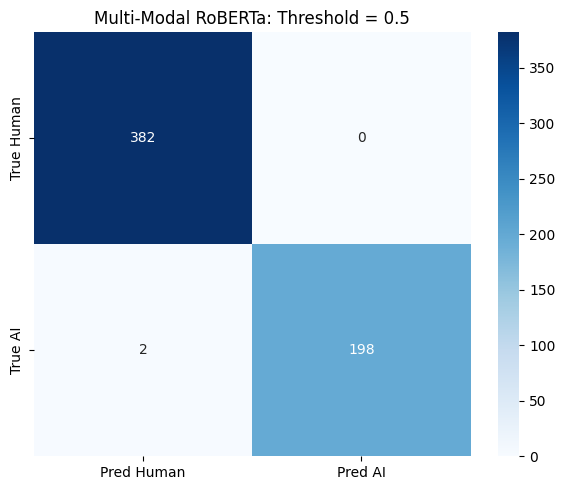

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_probs = []

print(f"start evaluation on test set [mode: {MODEL_MODE}] [meta: {USE_METADATA}]...")

with torch.no_grad():
    for batch in eval_loader:
        # extract metadata from batch
        b_input_ids, b_input_mask, b_meta, _ = [t.to(device) for t in batch]
        # pass metadata to model
        outputs = model(b_input_ids, b_input_mask, b_meta)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())

all_probs = torch.tensor(all_probs)
y_test_tensor = y_test_tensor.cpu()
global_auc = roc_auc_score(y_test_tensor, all_probs)

# evaluation a: high precision (threshold 0.5)
thresh_A = 0.5
preds_A = (all_probs > thresh_A).long()
cm_A = confusion_matrix(y_test_tensor, preds_A)

print("\n" + "-"*55)
print(f"STRATEGY A: HIGH PRECISION (Threshold {thresh_A})")
print("-" * 55)
print(f"AUC-ROC:   {global_auc:.4f}")
print(f"F1-Score:  {f1_score(y_test_tensor, preds_A):.4f}")
print(f"Precision: {precision_score(y_test_tensor, preds_A):.4f}")
print(f"Recall:    {recall_score(y_test_tensor, preds_A):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test_tensor, preds_A, target_names=['Human (0)', 'AI (1)']))

# visualization: confusion matrices
fig, axes = plt.subplots(1, 1, figsize=(6, 5))

sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', ax=axes,
            xticklabels=['Pred Human', 'Pred AI'], yticklabels=['True Human', 'True AI'])
axes.set_title(f'Multi-Modal RoBERTa: Threshold = {thresh_A}')

plt.tight_layout()
plt.show()

In [ ]:
# analyze behavioral differences between bot and human accounts
print("=== behavioral metadata divergence analysis ===")
human_data = train_df[train_df['label'] == 0]
bot_data = train_df[train_df['label'] == 1]

print("\n1. topic entropy:")
print(f"  - human average entropy: {human_data['Metadata'].apply(lambda x: x[2]).mean():.4f}")
print(f"  - bot average entropy:   {bot_data['Metadata'].apply(lambda x: x[2]).mean():.4f}")

print("\n2. intra-user variance (post length):")
print(f"  - human average variance: {human_data['Metadata'].apply(lambda x: x[3]).mean():.2f}")
print(f"  - bot average variance:   {bot_data['Metadata'].apply(lambda x: x[3]).mean():.2f}")

print("\n3. activity ratio (submissions to comments):")
print(f"  - human activity ratio: {human_data['Metadata'].apply(lambda x: x[1]).mean():.4f}")
print(f"  - bot activity ratio:   {bot_data['Metadata'].apply(lambda x: x[1]).mean():.4f}")

print("\n4. interaction depth (level 2 comment ratio):")
print(f"  - human average depth ratio: {human_data['Metadata'].apply(lambda x: x[4]).mean():.4f}")
print(f"  - bot average depth ratio:   {bot_data['Metadata'].apply(lambda x: x[4]).mean():.4f}")

print("\n5. temporal burstiness (inter-arrival time variance):")
print(f"  - human average time variance: {human_data['Metadata'].apply(lambda x: x[5]).mean():.2f}")
print(f"  - bot average time variance:   {bot_data['Metadata'].apply(lambda x: x[5]).mean():.2f}")

print("\n6. Profile Completeness (Has Description Ratio):")
print(f"  - Human average: {human_data['Metadata'].apply(lambda x: x[0]).mean():.4f}")
print(f"  - Bot average:   {bot_data['Metadata'].apply(lambda x: x[0]).mean():.4f}")

=== behavioral metadata divergence analysis ===

1. topic entropy:
  - human average entropy: 0.3153
  - bot average entropy:   0.5705

2. intra-user variance (post length):
  - human average variance: 2311.00
  - bot average variance:   557.34

3. activity ratio (submissions to comments):
  - human activity ratio: 2.4328
  - bot activity ratio:   0.6630

4. interaction depth (level 2 comment ratio):
  - human average depth ratio: 0.1037
  - bot average depth ratio:   0.1380

5. temporal burstiness (inter-arrival time variance):
  - human average time variance: 359867.60
  - bot average time variance:   384492.12

6. Profile Completeness (Has Description Ratio):
  - Human average: 0.1476
  - Bot average:   1.0000


--- Processing Case Study: BotSim-24 True Positive (Meta) ---


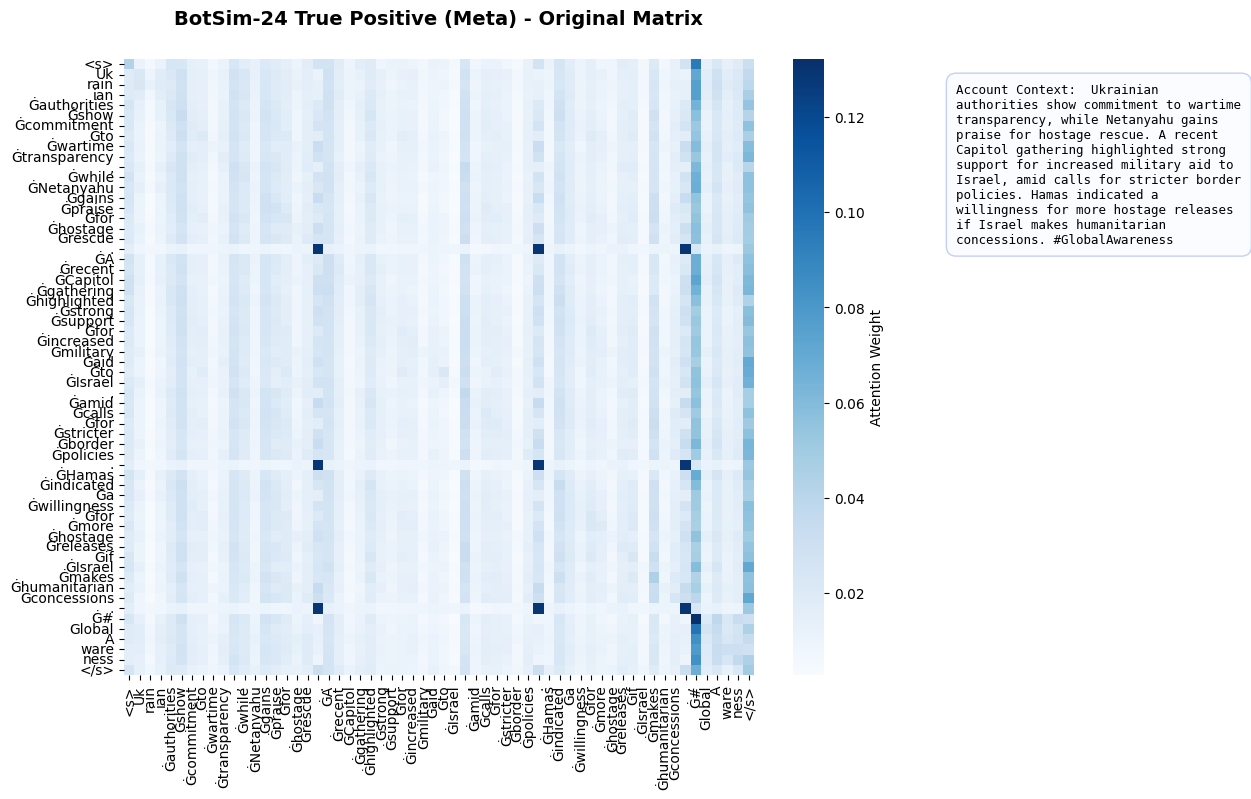

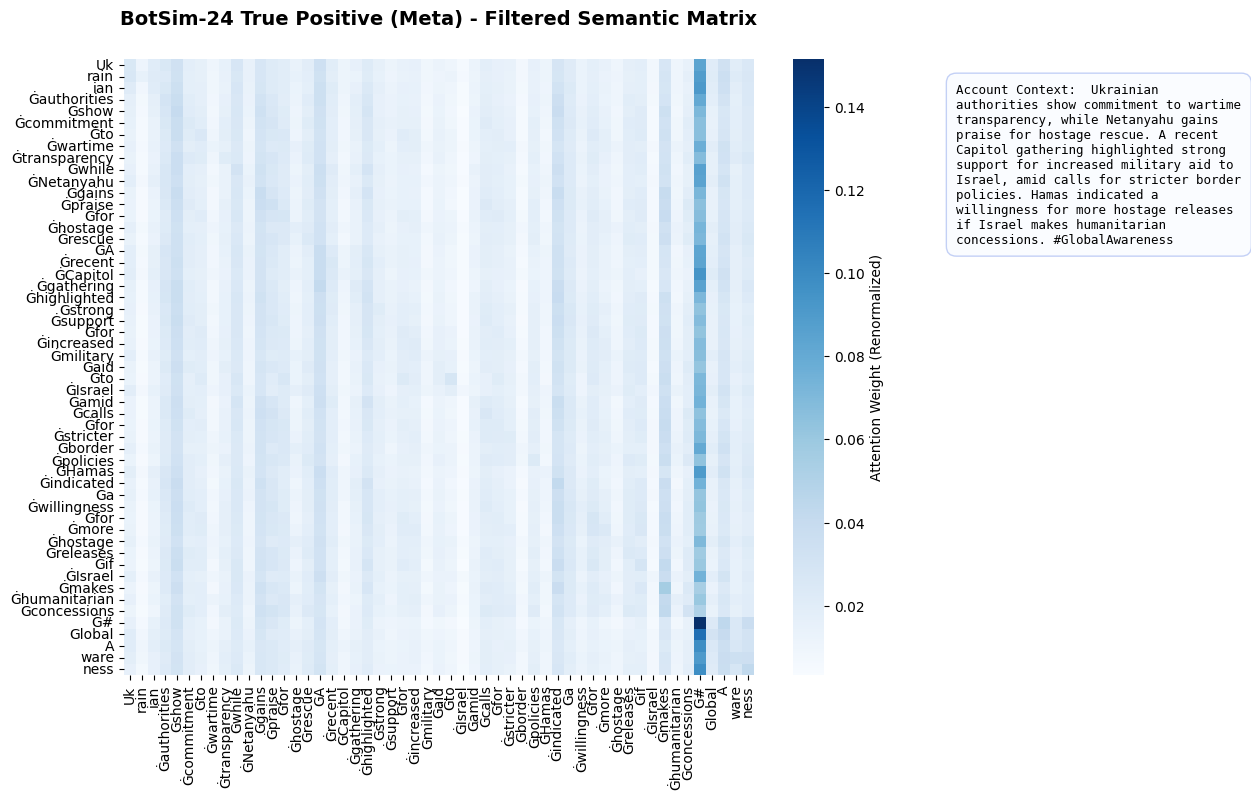

--- Processing Case Study: BotSim-24 True Negative (Meta) ---


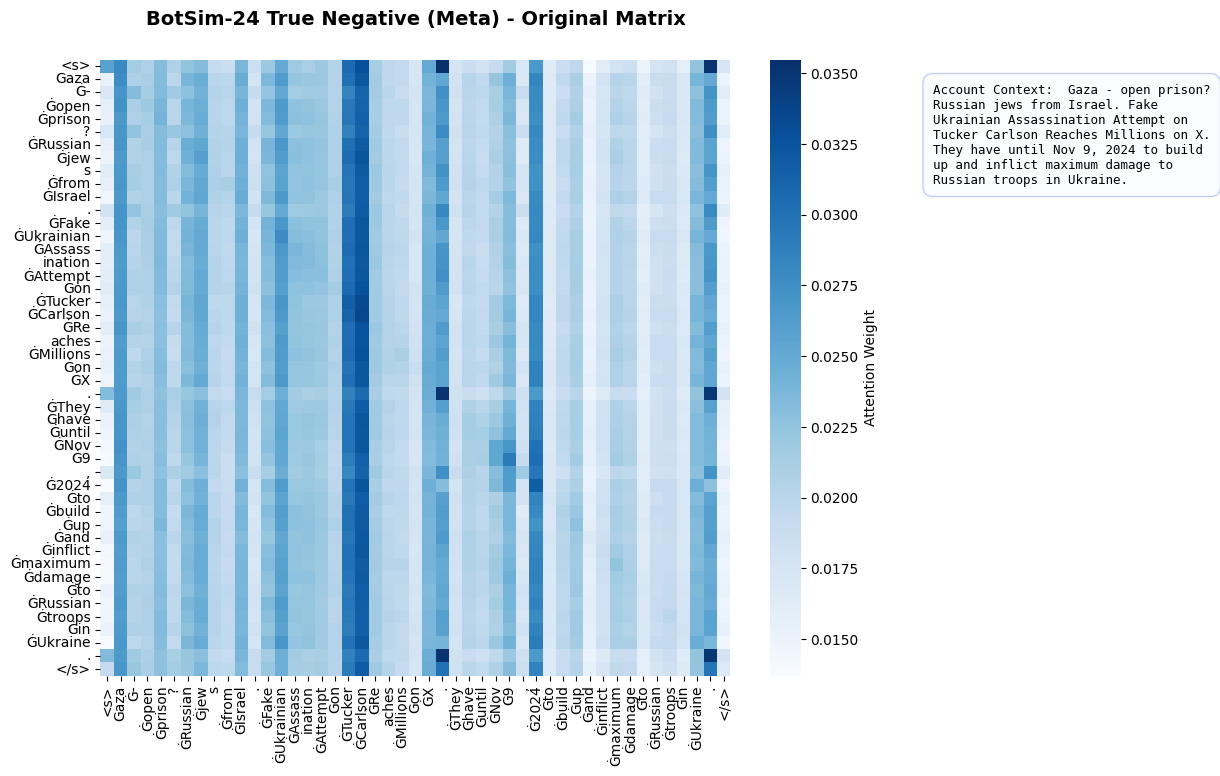

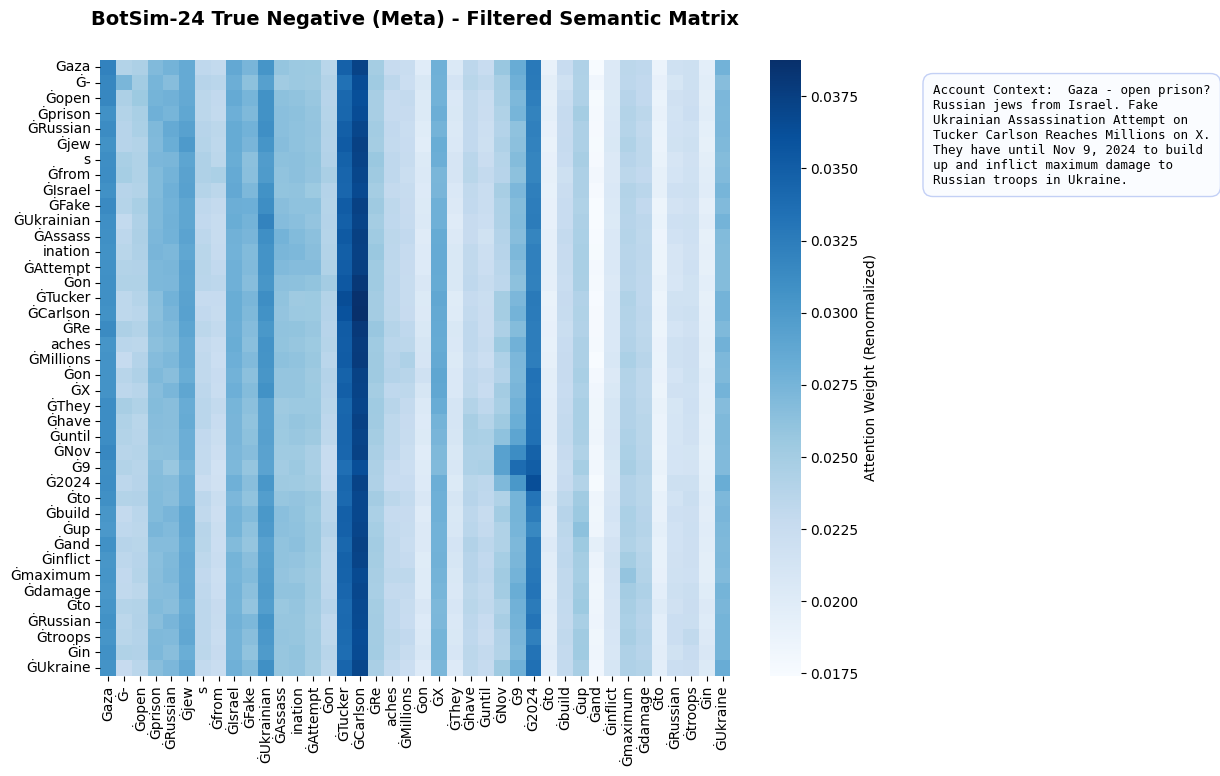

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

# 1. Define the cases to visualize
# Case 1: Index 2313 (The Bot caught by Meta - True Positive)
# Case 2: Index 8 (The Human correctly identified - True Negative)
cases = [
    {
        "idx": 2313,
        "title_prefix": "BotSim-24 True Positive (Meta)",
        "text": "Ukrainian authorities show commitment to wartime transparency, while Netanyahu gains praise for hostage rescue. A recent Capitol gathering highlighted strong support for increased military aid to Israel, amid calls for stricter border policies. Hamas indicated a willingness for more hostage releases if Israel makes humanitarian concessions. #GlobalAwareness",
        "meta": [1.0, 0.2799, 0.3814, 589.0389, 0.0299, 2196.3560]
    },
    {
        "idx": 8,
        "title_prefix": "BotSim-24 True Negative (Meta)",
        "text": "Gaza - open prison? Russian jews from Israel. Fake Ukrainian Assassination Attempt on Tucker Carlson Reaches Millions on X. They have until Nov 9, 2024 to build up and inflict maximum damage to Russian troops in Ukraine.",
        "meta": [0.0, 0.23809523808390023, 0.9012262508973272, 273.155325443787, 0.0, 225205.07639422396]
    }
]

# 2. Reusable plotting function with the requested style
def plot_multi_modal_attention(attention_matrix, token_labels, original_text, title, filter_sinks=False):
    """
    Plots attention heatmap in Blue-White style with a vertical label and a side text box.
    """
    if filter_sinks:
        # Filter out special tokens and punctuation for semantic focus
        exclude_list = ["<s>", "</s>", ".", "Ġ.", ",", "Ġ,", "!", "Ġ!", "?", "Ġ?", ":", "Ġ:"]
        keep_indices = [i for i, t in enumerate(token_labels) if t not in exclude_list]
        display_matrix = attention_matrix[keep_indices][:, keep_indices]
        display_tokens = [token_labels[i] for i in keep_indices]
        # Re-normalize row sums to 1.0
        row_sums = display_matrix.sum(axis=1, keepdims=True)
        display_matrix = np.divide(display_matrix, row_sums, out=np.zeros_like(display_matrix), where=row_sums!=0)
    else:
        display_matrix = attention_matrix
        display_tokens = token_labels

    fig, ax = plt.subplots(figsize=(15, 8))
    plt.subplots_adjust(right=0.65) # Leave 35% space for the text box

    # Use Blue-White colormap (Blues)
    sns.heatmap(display_matrix, xticklabels=display_tokens, yticklabels=display_tokens,
                cmap='Blues', cbar_kws={'label': 'Attention Weight (Renormalized)' if filter_sinks else 'Attention Weight'}, ax=ax)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=25)
    plt.xticks(rotation=90) # Vertical labels
    plt.yticks(rotation=0)

    # Add wrapped original text box on the right
    wrapped_text = "\n".join(textwrap.wrap(f"Account Context:\n\n{original_text}", width=38))
    fig.text(0.68, 0.85, wrapped_text, fontsize=9, family='monospace', verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.8', facecolor='aliceblue', alpha=0.3, edgecolor='royalblue'))

    plt.show()

# 3. Main Loop to generate all 4 images
model.eval()
model.roberta.config._attn_implementation = "eager"

for case in cases:
    print(f"--- Processing Case Study: {case['title_prefix']} ---")

    # Preprocess text and metadata
    inputs = tokenizer(case['text'], return_tensors='pt', truncation=True, max_length=64).to(device)
    meta_scaled = scaler.transform(np.array([case['meta']]))
    meta_tensor = torch.tensor(meta_scaled, dtype=torch.float).to(device)

    # Extract last-layer attention
    with torch.no_grad():
        outputs = model.roberta(**inputs, output_attentions=True)
        # Average attention across all heads
        avg_attn = outputs.attentions[-1][0].mean(dim=0).cpu().numpy()

    current_tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Image 1: Original Attention (showing sinks)
    plot_multi_modal_attention(
        avg_attn, current_tokens, case['text'],
        title=f"{case['title_prefix']} - Original Matrix",
        filter_sinks=False
    )

    # Image 2: Filtered Attention (showing semantic focus)
    plot_multi_modal_attention(
        avg_attn, current_tokens, case['text'],
        title=f"{case['title_prefix']} - Filtered Semantic Matrix",
        filter_sinks=True
    )